# EMBER2024 — Dataset Audit Notebook (Project-Level)

Notebook này dùng để **xem xét dataset của cả dự án** theo đúng tư duy pipeline:

- **Tầng 1:** phát hiện file có phải malware hay không (`label`)
- **Tầng 2:** chỉ trên các mẫu malware, xem xét các nhãn mở rộng:
  - `family`
  - `behavior`
  - `file_property`
  - `packer`
  - `exploit`
  - `group`
- `family_confidence` được xem là **độ tin cậy của nhãn family**, không phải mục tiêu phân loại chính
- `caps`, `ttps`, `mbc` chỉ xem như **thông tin mô tả thêm**, không dùng làm mục tiêu phân loại trong notebook này

## Mục tiêu của notebook
1. Hiểu cấu trúc thư mục dataset  
2. Hiểu cấu trúc mỗi record JSONL  
3. Thống kê dataset theo `train / test / challenge`  
4. Kiểm tra độ phủ các field và các block feature chính  
5. Kiểm tra phân bố `label`, `file_type`, timeline theo tuần  
6. Kiểm tra các nhãn mở rộng trên **malware-only**  
7. Rút ra kết luận xem dataset hỗ trợ được những bài toán nào trong dự án

## Bản đồ quy trình xem xét dataset

```text
Dataset root
   │
   ├── 1) Quét cấu trúc thư mục và file JSONL
   │
   ├── 2) Đọc record mẫu để hiểu schema tổng quát
   │
   ├── 3) Stream toàn bộ dataset để thống kê theo split
   │       ├── Label distribution
   │       ├── File type distribution
   │       ├── Timeline theo tuần
   │       ├── Field coverage
   │       ├── Feature-block coverage
   │       └── Numeric summary
   │
   ├── 4) Lọc malware-only
   │       ├── Family audit
   │       ├── Behavior audit
   │       ├── File property audit
   │       ├── Packer audit
   │       ├── Exploit audit
   │       ├── Group audit
   │       └── Family confidence audit
   │
   └── 5) Kết luận ở mức dự án
           ├── Dataset có gì?
           ├── Bài toán chính là gì?
           ├── Nhãn nào đủ tốt cho tầng 2?
           └── Điều gì cần lưu ý khi train model?
```

Notebook này **không phụ thuộc vào CSV summary**.  
Mọi thống kê được đọc **trực tiếp từ raw JSONL**.

In [1]:
from __future__ import annotations

import os
import re
import math
import json
import random
from pathlib import Path
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import Any, Dict, Iterable, Iterator, List, Optional, Tuple

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import orjson
    FAST_JSON = "orjson"
except Exception:
    orjson = None
    FAST_JSON = "json"

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

print(f"JSON backend: {FAST_JSON}")

JSON backend: json


In [2]:
# =========================
# Project dataset settings
# =========================

DATA_ROOT = Path(r"E:\project2\EMBER2024\data_pe")

# Để test nhanh, có thể bật FAST_MODE và giới hạn số file / số dòng mỗi file
FAST_MODE = False
MAX_FILES_PER_SPLIT = None          # ví dụ: 3
MAX_LINES_PER_FILE = None           # ví dụ: 5000

# Số record mẫu để xem schema / raw values
SCHEMA_SAMPLE_FILES_PER_SPLIT = 2
RAW_SAMPLE_RECORDS = 5

# Các split dự kiến
EXPECTED_SPLITS = ["train", "test", "challenge"]

# Các nhãn mở rộng của tầng 2
STAGE2_TARGETS = [
    "family",
    "behavior",
    "file_property",
    "packer",
    "exploit",
    "group",
]

SUPPORT_FIELDS = [
    "family_confidence",
]

# Các block feature quan trọng để train model tầng 1
FEATURE_BLOCKS = [
    "histogram",
    "byteentropy",
    "strings",
    "general",
    "header",
    "section",
    "imports",
    "exports",
    "datadirectories",
    "richheader",
    "authenticode",
    "pefilewarnings",
]

# Một số numeric field hữu ích để mô tả dataset
NUMERIC_PATHS = {
    "general.size": ("general", "size"),
    "general.vsize": ("general", "vsize"),
    "general.entropy": ("general", "entropy"),
    "general.is_pe": ("general", "is_pe"),
    "strings.numstrings": ("strings", "numstrings"),
    "strings.avlength": ("strings", "avlength"),
    "strings.printables": ("strings", "printables"),
    "imports.num_dlls": ("imports", "num_dlls"),
    "imports.num_funcs": ("imports", "num_funcs"),
}

random.seed(42)

print("DATA_ROOT =", DATA_ROOT)
print("FAST_MODE =", FAST_MODE)

DATA_ROOT = E:\project2\EMBER2024\data_pe
FAST_MODE = False


In [3]:
# Optional: thử import thrember nếu bạn đã cài hoặc có src/thrember
import sys

THREMBER_AVAILABLE = False
THREMBER_LOCATION = None

candidate_src = DATA_ROOT.parent / "src"
if candidate_src.exists() and str(candidate_src) not in sys.path:
    sys.path.insert(0, str(candidate_src))

try:
    import thrember  # noqa: F401
    THREMBER_AVAILABLE = True
    THREMBER_LOCATION = getattr(thrember, "__file__", "imported")
except Exception as e:
    THREMBER_AVAILABLE = False
    THREMBER_LOCATION = str(e)

print("thrember available:", THREMBER_AVAILABLE)
print("thrember location/info:", THREMBER_LOCATION)

e:\project2\EMBER2024\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


thrember available: True
thrember location/info: E:\project2\EMBER2024\src\thrember\__init__.py


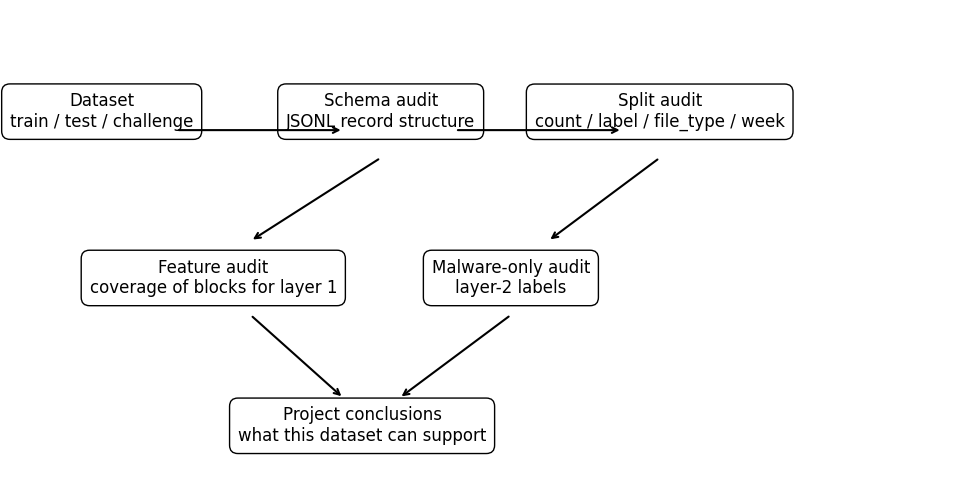

In [4]:
# =========================
# Visual overview for the project
# =========================

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis("off")

boxes = {
    "dataset": (0.08, 0.78, "Dataset\ntrain / test / challenge"),
    "schema": (0.38, 0.78, "Schema audit\nJSONL record structure"),
    "split": (0.68, 0.78, "Split audit\ncount / label / file_type / week"),
    "feature": (0.20, 0.42, "Feature audit\ncoverage of blocks for layer 1"),
    "malware": (0.52, 0.42, "Malware-only audit\nlayer-2 labels"),
    "conclusion": (0.36, 0.10, "Project conclusions\nwhat this dataset can support"),
}

for key, (x, y, text) in boxes.items():
    ax.text(
        x, y, text,
        ha="center", va="center", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black")
    )

arrows = [
    ((0.16, 0.74), (0.34, 0.74)),
    ((0.46, 0.74), (0.64, 0.74)),
    ((0.68, 0.68), (0.56, 0.50)),
    ((0.38, 0.68), (0.24, 0.50)),
    ((0.24, 0.34), (0.34, 0.16)),
    ((0.52, 0.34), (0.40, 0.16)),
]
for (x1, y1), (x2, y2) in arrows:
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.5))

plt.show()

In [5]:
# =========================
# Helpers
# =========================

FILENAME_RE = re.compile(
    r"(?P<start>\d{4}-\d{2}-\d{2})_(?P<end>\d{4}-\d{2}-\d{2})_(?P<file_type>.+)_(?P<subset>train|test|challenge)\.jsonl$"
)

def read_json_line(line: bytes | str) -> dict:
    if isinstance(line, str):
        raw = line.encode("utf-8")
    else:
        raw = line
    if orjson is not None:
        return orjson.loads(raw)
    return json.loads(raw.decode("utf-8"))

def iter_jsonl(path: Path, max_lines: Optional[int] = None) -> Iterator[dict]:
    with path.open("rb") as f:
        for i, line in enumerate(f, start=1):
            if max_lines is not None and i > max_lines:
                break
            line = line.strip()
            if not line:
                continue
            yield read_json_line(line)

def parse_filename(path: Path) -> dict:
    m = FILENAME_RE.match(path.name)
    info = {
        "path": str(path),
        "name": path.name,
        "subset_from_name": None,
        "week_start": None,
        "week_end": None,
        "file_type_from_name": None,
        "valid_name_pattern": False,
    }
    if m:
        info.update({
            "subset_from_name": m.group("subset"),
            "week_start": m.group("start"),
            "week_end": m.group("end"),
            "file_type_from_name": m.group("file_type"),
            "valid_name_pattern": True,
        })
    return info

def infer_split_from_path(path: Path) -> str:
    parts = [p.lower() for p in path.parts]
    for s in EXPECTED_SPLITS:
        if s in parts:
            return s
    return "unknown"

def is_nonempty(value: Any) -> bool:
    if value is None:
        return False
    if isinstance(value, float) and math.isnan(value):
        return False
    if isinstance(value, str):
        return value.strip() != ""
    if isinstance(value, (list, tuple, set, dict)):
        return len(value) > 0
    return True

def nested_get(d: dict, path: Tuple[str, ...], default=None):
    cur = d
    for key in path:
        if not isinstance(cur, dict):
            return default
        if key not in cur:
            return default
        cur = cur[key]
    return cur

def parse_detection_ratio(value: Any) -> Tuple[Optional[float], Optional[float]]:
    if value is None:
        return None, None
    if isinstance(value, str):
        if "/" in value:
            left, right = value.split("/", 1)
            try:
                return float(left), float(right)
            except Exception:
                return None, None
        try:
            v = float(value)
            return v, None
        except Exception:
            return None, None
    if isinstance(value, (int, float)):
        return float(value), None
    return None, None

def normalize_to_labels(value: Any) -> List[str]:
    if value is None:
        return []
    if isinstance(value, str):
        v = value.strip()
        return [v] if v else []
    if isinstance(value, (int, float, bool)):
        return [str(value)]
    if isinstance(value, dict):
        labels = []
        for k, v in value.items():
            if isinstance(v, bool):
                if v:
                    labels.append(str(k))
            elif isinstance(v, (int, float)):
                if v not in (0, 0.0):
                    labels.append(f"{k}={v}")
            elif is_nonempty(v):
                labels.append(str(k))
        return labels
    if isinstance(value, (list, tuple, set)):
        labels = []
        for item in value:
            labels.extend(normalize_to_labels(item))
        return [x for x in labels if x]
    return [str(value)]

def classify_value_shape(value: Any) -> str:
    if value is None:
        return "none"
    if isinstance(value, str):
        return "string"
    if isinstance(value, bool):
        return "bool"
    if isinstance(value, int):
        return "int"
    if isinstance(value, float):
        return "float"
    if isinstance(value, list):
        return "list"
    if isinstance(value, tuple):
        return "tuple"
    if isinstance(value, dict):
        return "dict"
    return type(value).__name__

@dataclass
class RunningStats:
    n: int = 0
    mean: float = 0.0
    m2: float = 0.0
    min: Optional[float] = None
    max: Optional[float] = None

    def update(self, value: Optional[float]):
        if value is None:
            return
        try:
            x = float(value)
        except Exception:
            return
        self.n += 1
        delta = x - self.mean
        self.mean += delta / self.n
        delta2 = x - self.mean
        self.m2 += delta * delta2
        self.min = x if self.min is None else min(self.min, x)
        self.max = x if self.max is None else max(self.max, x)

    @property
    def std(self) -> Optional[float]:
        if self.n < 2:
            return None
        return math.sqrt(self.m2 / (self.n - 1))

    def to_dict(self):
        return {
            "count": self.n,
            "mean": self.mean if self.n else None,
            "std": self.std,
            "min": self.min,
            "max": self.max,
        }

## Bước 1 — Quét cấu trúc thư mục và file JSONL

Cell dưới đây sẽ:
- tìm tất cả file `.jsonl`
- xác định split theo thư mục
- bóc tách tuần và `file_type` từ tên file
- tạo bảng chỉ mục file của dataset

In [6]:
all_jsonl_files = sorted(DATA_ROOT.rglob("*.jsonl"))

if FAST_MODE and MAX_FILES_PER_SPLIT is not None:
    limited = []
    per_split_counter = Counter()
    for p in all_jsonl_files:
        split = infer_split_from_path(p)
        if per_split_counter[split] < MAX_FILES_PER_SPLIT:
            limited.append(p)
            per_split_counter[split] += 1
    all_jsonl_files = limited

file_rows = []
for path in all_jsonl_files:
    info = parse_filename(path)
    info["split"] = infer_split_from_path(path)
    info["size_bytes"] = path.stat().st_size
    info["size_gb"] = path.stat().st_size / (1024 ** 3)
    file_rows.append(info)

file_index_df = pd.DataFrame(file_rows).sort_values(["split", "week_start", "file_type_from_name", "name"]).reset_index(drop=True)
display(file_index_df.head(10))

print("Total JSONL files found:", len(file_index_df))
print(file_index_df["split"].value_counts(dropna=False).to_string())

,path,name,subset_from_name,week_start,week_end,file_type_from_name,valid_name_pattern,split,size_bytes,size_gb
0,E:\project2\EMBER2024\data_pe\challenge\2023-09-24_2023-09-30_challenge_malicious.jsonl,2023-09-24_2023-09-30_challenge_malicious.jsonl,NaN,NaN,NaN,NaN,False,challenge,1706714,0.001590
1,E:\project2\EMBER2024\data_pe\challenge\2023-10-01_2023-10-07_challenge_malicious.jsonl,2023-10-01_2023-10-07_challenge_malicious.jsonl,NaN,NaN,NaN,NaN,False,challenge,1125076,0.001048
2,E:\project2\EMBER2024\data_pe\challenge\2023-10-08_2023-10-14_challenge_malicious.jsonl,2023-10-08_2023-10-14_challenge_malicious.jsonl,NaN,NaN,NaN,NaN,False,challenge,1387378,0.001292
3,E:\project2\EMBER2024\data_pe\challenge\2023-10-15_2023-10-21_challenge_malicious.jsonl,2023-10-15_2023-10-21_challenge_malicious.jsonl,NaN,NaN,NaN,NaN,False,challenge,1885218,0.001756
4,E:\project2\EMBER2024\data_pe\challenge\2023-10-22_2023-10-28_challenge_malicious.jsonl,2023-10-22_2023-10-28_challenge_malicious.jsonl,NaN,NaN,NaN,NaN,False,challenge,3797401,0.003537
5,E:\project2\EMBER2024\data_pe\challenge\2023-10-29_2023-11-04_challenge_malicious.jsonl,2023-10-29_2023-11-04_challenge_malicious.jsonl,NaN,NaN,NaN,NaN,False,challenge,3220049,0.002999
6,E:\project2\EMBER2024\data_pe\challenge\2023-11-05_2023-11-11_challenge_malicious.jsonl,2023-11-05_2023-11-11_challenge_malicious.jsonl,NaN,NaN,NaN,NaN,False,challenge,6722588,0.006261
7,E:\project2\EMBER2024\data_pe\challenge\2023-11-12_2023-11-18_challenge_malicious.jsonl,2023-11-12_2023-11-18_challenge_malicious.jsonl,NaN,NaN,NaN,NaN,False,challenge,3667197,0.003415
8,E:\project2\EMBER2024\data_pe\challenge\2023-11-19_2023-11-25_challenge_malicious.jsonl,2023-11-19_2023-11-25_challenge_malicious.jsonl,NaN,NaN,NaN,NaN,False,challenge,7388336,0.006881
9,E:\project2\EMBER2024\data_pe\challenge\2023-11-26_2023-12-02_challenge_malicious.jsonl,2023-11-26_2023-12-02_challenge_malicious.jsonl,NaN,NaN,NaN,NaN,False,challenge,5778753,0.005382


Total JSONL files found: 256
split
train        156
challenge     64
test          36


In [7]:
if file_index_df.empty:
    raise FileNotFoundError(
        f"Không tìm thấy file JSONL trong {DATA_ROOT}. "
        "Hãy kiểm tra lại DATA_ROOT trước khi chạy tiếp."
    )

file_overview_df = (
    file_index_df.groupby("split", dropna=False)
    .agg(
        n_files=("name", "count"),
        total_size_gb=("size_gb", "sum"),
        first_week=("week_start", "min"),
        last_week=("week_end", "max"),
        n_file_types=("file_type_from_name", "nunique"),
    )
    .reset_index()
)
display(file_overview_df)

,split,n_files,total_size_gb,first_week,last_week,n_file_types
0,challenge,64,0.151005,NaN,NaN,0
1,test,36,16.442888,2024-09-22,2024-12-14,3
2,train,156,80.430366,2023-09-24,2024-09-21,3


## Bước 2 — Xem record mẫu để hiểu schema tổng quát

Mục đích:
- xem 1 record thật trong JSONL trông như thế nào
- xem top-level fields có những gì
- xác định các block feature nào đang tồn tại

In [8]:
sample_records = []
sample_sources = []

for split in EXPECTED_SPLITS:
    split_files = file_index_df[file_index_df["split"] == split]["path"].tolist()
    for fp in split_files[:SCHEMA_SAMPLE_FILES_PER_SPLIT]:
        p = Path(fp)
        try:
            first_record = next(iter_jsonl(p, max_lines=1))
            sample_records.append(first_record)
            sample_sources.append({"split": split, "file": p.name})
        except StopIteration:
            pass

print("Number of sampled records:", len(sample_records))
pd.DataFrame(sample_sources)

Number of sampled records: 6


,split,file
0,train,2023-09-24_2023-09-30_Dot_Net_train.jsonl
1,train,2023-09-24_2023-09-30_Win32_train.jsonl
2,test,2024-09-22_2024-09-28_Dot_Net_test.jsonl
3,test,2024-09-22_2024-09-28_Win32_test.jsonl
4,challenge,2023-09-24_2023-09-30_challenge_malicious.jsonl
5,challenge,2023-10-01_2023-10-07_challenge_malicious.jsonl


In [9]:
if sample_records:
    first = sample_records[0]
    print("Top-level fields of a sample record:")
    print(sorted(first.keys()))

    simplified = {}
    for k, v in first.items():
        if isinstance(v, dict):
            simplified[k] = {
                "_type": "dict",
                "_keys": list(v.keys())[:12],
                "_len": len(v),
            }
        elif isinstance(v, list):
            simplified[k] = {
                "_type": "list",
                "_len": len(v),
                "_sample": v[:3],
            }
        else:
            simplified[k] = v

    sample_view_df = pd.DataFrame({
        "field": list(simplified.keys()),
        "python_type": [classify_value_shape(v) for v in first.values()],
        "preview": [str(simplified[k])[:200] for k in simplified.keys()],
    })
    display(sample_view_df)
else:
    print("Không lấy được sample record nào.")

Top-level fields of a sample record:
['authenticode', 'behavior', 'byteentropy', 'caps', 'datadirectories', 'detection_ratio', 'exploit', 'exports', 'family', 'family_confidence', 'file_property', 'file_type', 'first_submission_date', 'general', 'group', 'header', 'histogram', 'imports', 'label', 'last_analysis_date', 'mbc', 'md5', 'packer', 'pefilewarnings', 'richheader', 'section', 'sha1', 'sha256', 'strings', 'tlsh', 'ttps', 'week_id']


,field,python_type,preview
0,md5,string,9114262d74901a45cf570acb14ce7590
1,sha1,string,448ca731b41d9a8bbe2688a872c307ad4634e549
2,sha256,string,002bafa236ab2488ca15a6ba7691ffafc88e9c6f3394626eab305672e13ba88a
3,tlsh,string,T1BC744B34E3E84A3AF75F87F6D8330893E3B07251F1D9EB9DA988E1E8144671594065B3
4,first_submission_date,int,1695700667
5,last_analysis_date,int,1720278416
6,detection_ratio,string,0/77
7,label,int,0
8,file_type,string,Dot_Net
9,family,none,None


## Bước 3 — Stream toàn bộ dataset để thống kê theo split

Đây là phần quan trọng nhất của notebook.

Notebook sẽ đọc trực tiếp từng record trong raw JSONL và thống kê:
- số record theo split
- phân bố `label`
- phân bố `file_type`
- timeline theo `week_id` hoặc theo tên file
- coverage của field và block feature
- numeric summary
- malware-only label audit cho tầng 2

In [10]:
# =========================
# Full dataset streaming audit
# =========================

top_level_field_counter = defaultdict(Counter)             # split -> Counter(field present)
feature_block_counter = defaultdict(Counter)              # split -> Counter(block present)
label_counter = defaultdict(Counter)                      # split -> Counter(label)
file_type_counter = defaultdict(Counter)                  # split -> Counter(file_type)
week_counter = defaultdict(Counter)                       # split -> Counter(week)
records_per_week_type = defaultdict(Counter)              # split -> Counter((week, file_type))
numeric_stats = defaultdict(lambda: defaultdict(RunningStats))  # split -> metric -> stats

# Malware-only / stage-2 audit
malware_records = Counter()                               # split -> malware rows
stage2_presence_counter = defaultdict(Counter)            # split -> Counter(field present)
stage2_value_counter = defaultdict(lambda: defaultdict(Counter))  # split -> field -> Counter(label value)
stage2_shape_counter = defaultdict(lambda: defaultdict(Counter))  # split -> field -> Counter(shape)
support_presence_counter = defaultdict(Counter)           # split -> Counter(field present)
support_shape_counter = defaultdict(lambda: defaultdict(Counter)) # split -> field -> Counter(shape)
support_value_counter = defaultdict(lambda: defaultdict(Counter)) # split -> field -> Counter(value)

# General project counters
records_total = Counter()
bad_json_rows = Counter()

# Raw examples for stage-2 fields
stage2_examples = defaultdict(lambda: defaultdict(list))  # split -> field -> examples
support_examples = defaultdict(lambda: defaultdict(list)) # split -> field -> examples

progress_every = 200_000

for _, row in file_index_df.iterrows():
    path = Path(row["path"])
    split = row["split"]
    file_type_from_name = row["file_type_from_name"]
    week_from_name = row["week_start"]

    for idx, record in enumerate(iter_jsonl(path, max_lines=MAX_LINES_PER_FILE if FAST_MODE else None), start=1):
        try:
            records_total[split] += 1

            # Label
            label = record.get("label")
            label_counter[split][label] += 1

            # File type
            file_type = record.get("file_type", file_type_from_name)
            file_type_counter[split][file_type] += 1

            # Week
            week_value = record.get("week_id", week_from_name)
            week_counter[split][week_value] += 1
            records_per_week_type[split][(week_value, file_type)] += 1

            # Top-level fields coverage
            for field_name, field_value in record.items():
                if is_nonempty(field_value):
                    top_level_field_counter[split][field_name] += 1

            # Feature blocks coverage
            for block in FEATURE_BLOCKS:
                if is_nonempty(record.get(block)):
                    feature_block_counter[split][block] += 1

            # Numeric metrics
            det_hits, det_total = parse_detection_ratio(record.get("detection_ratio"))
            numeric_stats[split]["detection.hits"].update(det_hits)
            numeric_stats[split]["detection.total"].update(det_total)

            for metric_name, path_tuple in NUMERIC_PATHS.items():
                numeric_stats[split][metric_name].update(nested_get(record, path_tuple))

            # Malware-only audit
            if label == 1:
                malware_records[split] += 1

                for field_name in STAGE2_TARGETS:
                    value = record.get(field_name)
                    if is_nonempty(value):
                        stage2_presence_counter[split][field_name] += 1
                    shape = classify_value_shape(value)
                    stage2_shape_counter[split][field_name][shape] += 1

                    labels = normalize_to_labels(value)
                    for lab in labels:
                        stage2_value_counter[split][field_name][lab] += 1

                    if labels and len(stage2_examples[split][field_name]) < 5:
                        stage2_examples[split][field_name].append(value)

                for field_name in SUPPORT_FIELDS:
                    value = record.get(field_name)
                    if is_nonempty(value):
                        support_presence_counter[split][field_name] += 1
                    shape = classify_value_shape(value)
                    support_shape_counter[split][field_name][shape] += 1

                    labels = normalize_to_labels(value)
                    for lab in labels:
                        support_value_counter[split][field_name][lab] += 1

                    if labels and len(support_examples[split][field_name]) < 5:
                        support_examples[split][field_name].append(value)

            if records_total[split] % progress_every == 0:
                print(f"[{split}] processed {records_total[split]:,} rows")

        except Exception:
            bad_json_rows[split] += 1

print("Streaming audit done.")
print("records_total =", dict(records_total))
print("bad_json_rows =", dict(bad_json_rows))
print("malware_records =", dict(malware_records))

[test] processed 200,000 rows
[test] processed 400,000 rows
[test] processed 600,000 rows
[test] processed 800,000 rows
[test] processed 1,000,000 rows
[train] processed 200,000 rows
[train] processed 400,000 rows
[train] processed 600,000 rows
[train] processed 800,000 rows
[train] processed 1,000,000 rows
[train] processed 1,200,000 rows
[train] processed 1,400,000 rows
[train] processed 1,600,000 rows
[train] processed 1,800,000 rows
[train] processed 2,000,000 rows
[train] processed 2,200,000 rows
[train] processed 2,400,000 rows
[train] processed 2,600,000 rows
[train] processed 2,800,000 rows
[train] processed 3,000,000 rows
[train] processed 3,200,000 rows
[train] processed 3,400,000 rows
[train] processed 3,600,000 rows
[train] processed 3,800,000 rows
[train] processed 4,000,000 rows
[train] processed 4,200,000 rows
[train] processed 4,400,000 rows
[train] processed 4,600,000 rows
Streaming audit done.
records_total = {'challenge': 6315, 'test': 1080000, 'train': 4680000}
bad_

## Bước 4 — Tổng quan theo split

Phần này trả lời nhanh các câu hỏi:
- Mỗi split có bao nhiêu record?
- Benign / malware phân bố ra sao?
- `file_type` phân bố ra sao?
- timeline theo tuần có liên tục không?

In [11]:
overview_rows = []
for split in EXPECTED_SPLITS:
    n_records = records_total[split]
    n_files = int((file_index_df["split"] == split).sum())
    n_malware = label_counter[split].get(1, 0)
    n_benign = label_counter[split].get(0, 0)

    overview_rows.append({
        "split": split,
        "n_files": n_files,
        "n_records": n_records,
        "n_malware": n_malware,
        "n_benign": n_benign,
        "malware_ratio": (n_malware / n_records) if n_records else np.nan,
        "first_week": min([x for x in week_counter[split].keys() if x is not None], default=None),
        "last_week": max([x for x in week_counter[split].keys() if x is not None], default=None),
        "n_unique_weeks": len([x for x in week_counter[split].keys() if x is not None]),
        "n_unique_file_types": len([x for x in file_type_counter[split].keys() if x is not None]),
    })

overview_df = pd.DataFrame(overview_rows)
display(overview_df)

,split,n_files,n_records,n_malware,n_benign,malware_ratio,first_week,last_week,n_unique_weeks,n_unique_file_types
0,train,156,4680000,2340000,2340000,0.5,0,51,52,3
1,test,36,1080000,540000,540000,0.5,52,63,12,3
2,challenge,64,6315,6315,0,1.0,0,63,64,6


,split,label,count,ratio
4,challenge,1,6315,1.0
2,test,0,540000,0.5
3,test,1,540000,0.5
0,train,0,2340000,0.5
1,train,1,2340000,0.5


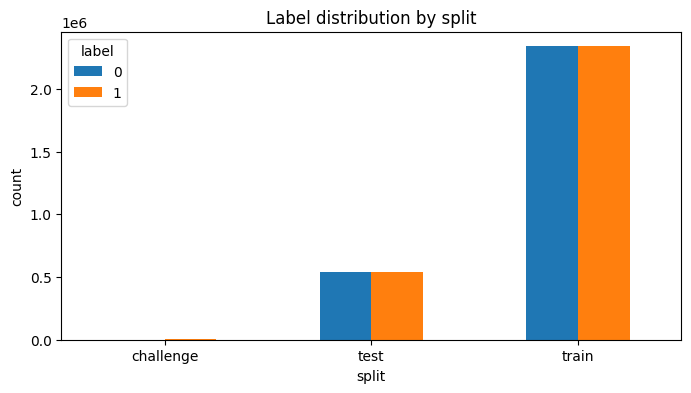

In [12]:
label_dist_rows = []
for split in EXPECTED_SPLITS:
    total = records_total[split]
    for label, cnt in sorted(label_counter[split].items(), key=lambda x: str(x[0])):
        label_dist_rows.append({
            "split": split,
            "label": label,
            "count": cnt,
            "ratio": cnt / total if total else np.nan,
        })

label_dist_df = pd.DataFrame(label_dist_rows).sort_values(["split", "label"])
display(label_dist_df)

if not label_dist_df.empty:
    pivot = label_dist_df.pivot(index="split", columns="label", values="count").fillna(0)
    pivot.plot(kind="bar", figsize=(8, 4), title="Label distribution by split")
    plt.ylabel("count")
    plt.xticks(rotation=0)
    plt.show()

,split,file_type,count,ratio
0,train,Win32,3120000,0.666667
1,train,Win64,1040000,0.222222
2,train,Dot_Net,520000,0.111111
3,test,Win32,720000,0.666667
4,test,Win64,240000,0.222222
5,test,Dot_Net,120000,0.111111
6,challenge,Win32,3225,0.510689
7,challenge,Dot_Net,829,0.131275
8,challenge,Win64,814,0.128899
9,challenge,PDF,805,0.127474


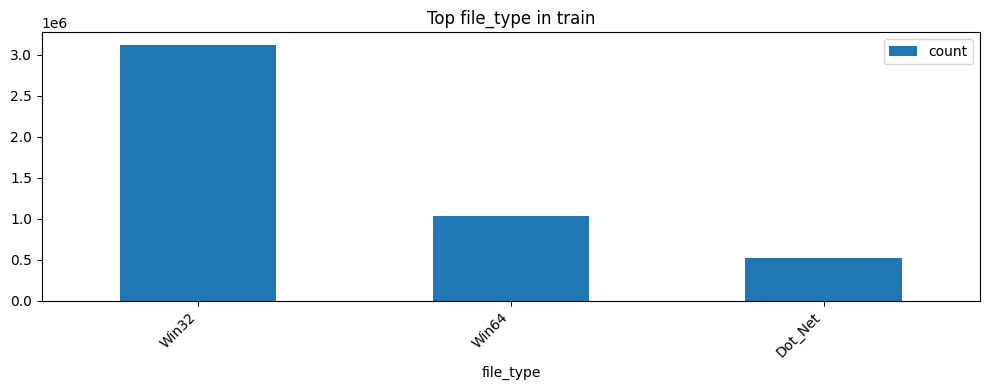

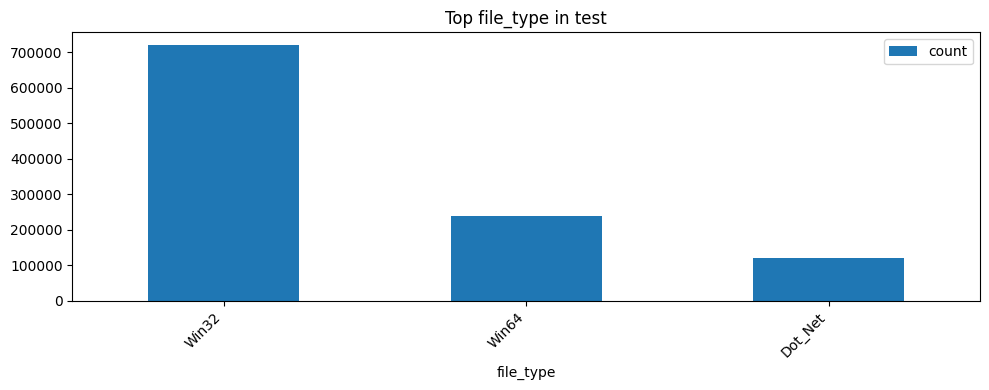

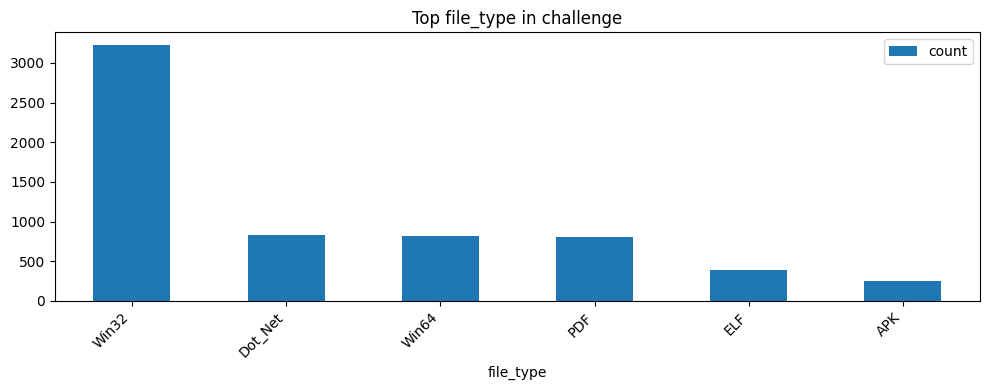

In [13]:
file_type_rows = []
for split in EXPECTED_SPLITS:
    total = records_total[split]
    for ft, cnt in file_type_counter[split].most_common():
        file_type_rows.append({
            "split": split,
            "file_type": ft,
            "count": cnt,
            "ratio": cnt / total if total else np.nan,
        })

file_type_dist_df = pd.DataFrame(file_type_rows)
display(file_type_dist_df.head(30))

if not file_type_dist_df.empty:
    for split in EXPECTED_SPLITS:
        sub = file_type_dist_df[file_type_dist_df["split"] == split].sort_values("count", ascending=False).head(12)
        if sub.empty:
            continue
        ax = sub.plot(kind="bar", x="file_type", y="count", figsize=(10, 4), title=f"Top file_type in {split}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

,split,week,count
0,train,0,90000
1,train,1,90000
2,train,10,90000
3,train,11,90000
4,train,12,90000
5,train,13,90000
6,train,14,90000
7,train,15,90000
8,train,16,90000
9,train,17,90000


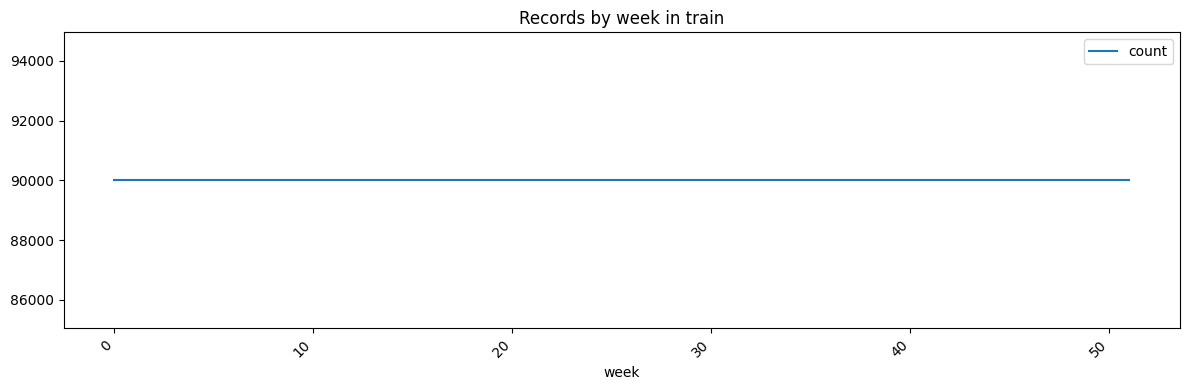

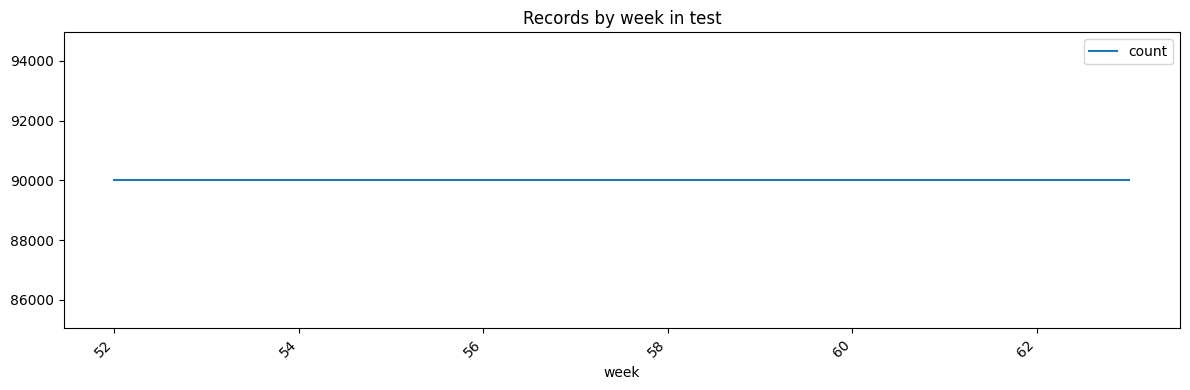

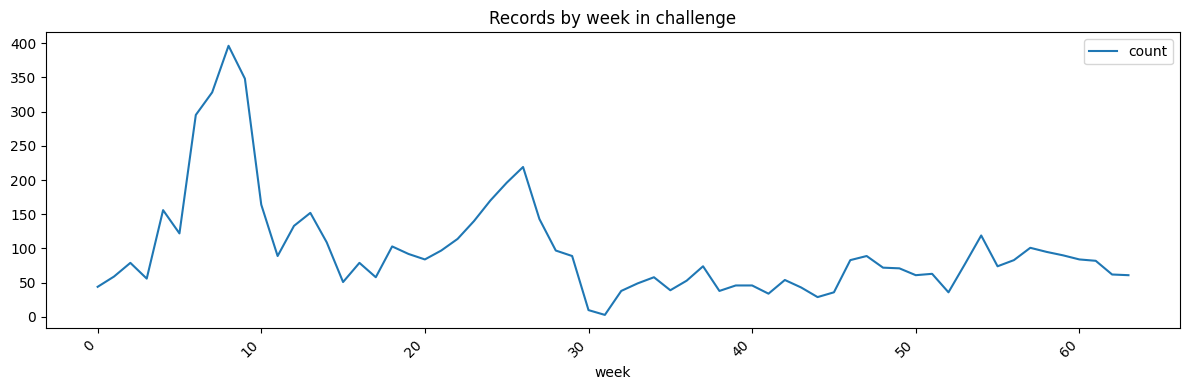

In [14]:
week_rows = []
for split in EXPECTED_SPLITS:
    for wk, cnt in sorted(week_counter[split].items(), key=lambda x: (str(x[0]))):
        week_rows.append({"split": split, "week": wk, "count": cnt})

week_df = pd.DataFrame(week_rows)
display(week_df.head(20))

if not week_df.empty:
    for split in EXPECTED_SPLITS:
        sub = week_df[week_df["split"] == split].copy()
        if sub.empty:
            continue
        sub = sub.sort_values("week")
        ax = sub.plot(kind="line", x="week", y="count", figsize=(12, 4), title=f"Records by week in {split}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

In [15]:
week_type_rows = []
for split in EXPECTED_SPLITS:
    for (wk, ft), cnt in records_per_week_type[split].items():
        week_type_rows.append({
            "split": split,
            "week": wk,
            "file_type": ft,
            "count": cnt,
        })

week_type_df = pd.DataFrame(week_type_rows)
display(week_type_df.head(20))

if not week_type_df.empty:
    for split in EXPECTED_SPLITS:
        sub = week_type_df[week_type_df["split"] == split]
        if sub.empty:
            continue
        pivot = sub.pivot_table(index="week", columns="file_type", values="count", aggfunc="sum", fill_value=0).sort_index()
        display(Markdown(f"### Week × file_type for `{split}`"))
        display(pivot.head(20))

,split,week,file_type,count
0,train,0,Dot_Net,10000
1,train,0,Win32,60000
2,train,0,Win64,20000
3,train,1,Dot_Net,10000
4,train,1,Win32,60000
5,train,1,Win64,20000
6,train,2,Dot_Net,10000
7,train,2,Win32,60000
8,train,2,Win64,20000
9,train,3,Dot_Net,10000


### Week × file_type for `train`

file_type,Dot_Net,Win32,Win64
week,,,
0,10000,60000,20000
1,10000,60000,20000
2,10000,60000,20000
3,10000,60000,20000
4,10000,60000,20000
5,10000,60000,20000
6,10000,60000,20000
7,10000,60000,20000
8,10000,60000,20000


### Week × file_type for `test`

file_type,Dot_Net,Win32,Win64
week,,,
52,10000,60000,20000
53,10000,60000,20000
54,10000,60000,20000
55,10000,60000,20000
56,10000,60000,20000
57,10000,60000,20000
58,10000,60000,20000
59,10000,60000,20000
60,10000,60000,20000


### Week × file_type for `challenge`

file_type,APK,Dot_Net,ELF,PDF,Win32,Win64
week,,,,,,
0,0,3,2,2,32,5
1,0,4,2,6,39,8
2,0,7,5,11,44,12
3,0,4,5,3,39,5
4,0,17,6,14,116,3
5,0,4,1,8,106,3
6,0,3,5,87,195,5
7,0,10,99,2,212,5
8,0,50,1,0,338,7


## Bước 5 — Độ phủ field và block feature của tầng 1

Phần này rất quan trọng cho mô hình phát hiện malware (`label`).

Ta cần biết:
- field nào gần như luôn có mặt
- block feature nào ổn định
- block nào thưa hoặc thiếu nhiều

In [16]:
field_coverage_rows = []
for split in EXPECTED_SPLITS:
    total = records_total[split]
    all_fields = sorted(set(top_level_field_counter[split].keys()))
    for field_name in all_fields:
        cnt = top_level_field_counter[split][field_name]
        field_coverage_rows.append({
            "split": split,
            "field": field_name,
            "nonempty_count": cnt,
            "coverage_ratio": cnt / total if total else np.nan,
        })

field_coverage_df = pd.DataFrame(field_coverage_rows).sort_values(["split", "coverage_ratio", "field"], ascending=[True, False, True])
display(field_coverage_df.head(50))

,split,field,nonempty_count,coverage_ratio
66,challenge,byteentropy,6315,1.000000
69,challenge,detection_ratio,6315,1.000000
75,challenge,file_type,6315,1.000000
76,challenge,first_submission_date,6315,1.000000
77,challenge,general,6315,1.000000
80,challenge,histogram,6315,1.000000
82,challenge,label,6315,1.000000
83,challenge,last_analysis_date,6315,1.000000
85,challenge,md5,6315,1.000000
90,challenge,sha1,6315,1.000000


,split,feature_block,nonempty_count,coverage_ratio
24,challenge,histogram,6315,1.000000
25,challenge,byteentropy,6315,1.000000
26,challenge,strings,6315,1.000000
27,challenge,general,6315,1.000000
28,challenge,header,4868,0.770863
29,challenge,section,4868,0.770863
32,challenge,datadirectories,4868,0.770863
34,challenge,authenticode,4868,0.770863
30,challenge,imports,4763,0.754236
33,challenge,richheader,3371,0.533808


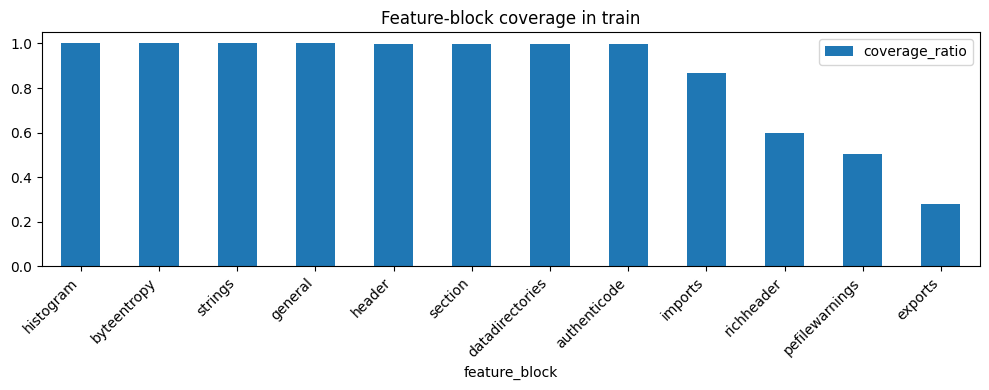

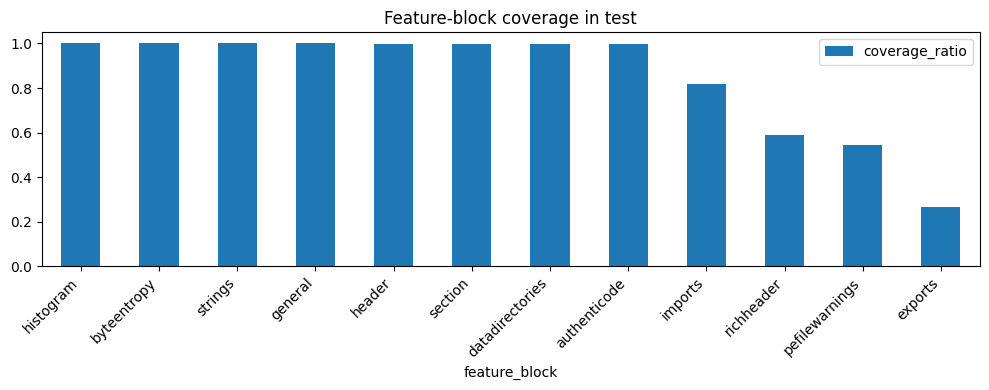

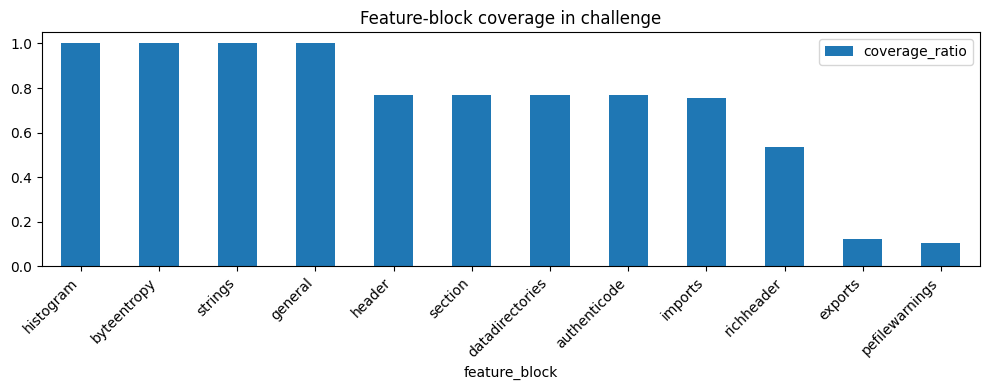

In [17]:
feature_block_rows = []
for split in EXPECTED_SPLITS:
    total = records_total[split]
    for block in FEATURE_BLOCKS:
        cnt = feature_block_counter[split][block]
        feature_block_rows.append({
            "split": split,
            "feature_block": block,
            "nonempty_count": cnt,
            "coverage_ratio": cnt / total if total else np.nan,
        })

feature_block_df = pd.DataFrame(feature_block_rows).sort_values(["split", "coverage_ratio"], ascending=[True, False])
display(feature_block_df)

if not feature_block_df.empty:
    for split in EXPECTED_SPLITS:
        sub = feature_block_df[feature_block_df["split"] == split].sort_values("coverage_ratio", ascending=False)
        if sub.empty:
            continue
        ax = sub.plot(kind="bar", x="feature_block", y="coverage_ratio", figsize=(10, 4), title=f"Feature-block coverage in {split}")
        plt.ylim(0, 1.05)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

## Bước 6 — Numeric summary của dataset

Phần này giúp quan sát nhanh các tín hiệu như:
- kích thước file
- entropy
- số string
- độ dài string trung bình
- số DLL / hàm import
- detection ratio

In [18]:
numeric_rows = []
for split in EXPECTED_SPLITS:
    for metric_name, stats_obj in numeric_stats[split].items():
        d = stats_obj.to_dict()
        d["split"] = split
        d["metric"] = metric_name
        numeric_rows.append(d)

numeric_summary_df = pd.DataFrame(numeric_rows).sort_values(["split", "metric"]).reset_index(drop=True)
display(numeric_summary_df)

,count,mean,std,min,max,split,metric
0,6315,1.298702e+01,7.847664e+00,5.000000,6.200000e+01,challenge,detection.hits
1,6315,7.583215e+01,1.659199e+00,65.000000,7.700000e+01,challenge,detection.total
2,6315,6.802875e+00,1.111477e+00,0.059125,7.999994e+00,challenge,general.entropy
3,6315,7.708630e-01,4.203108e-01,0.000000,1.000000e+00,challenge,general.is_pe
4,6315,2.535563e+07,3.000957e+07,877.000000,9.967979e+07,challenge,general.size
5,0,NaN,NaN,NaN,NaN,challenge,general.vsize
6,0,NaN,NaN,NaN,NaN,challenge,imports.num_dlls
7,0,NaN,NaN,NaN,NaN,challenge,imports.num_funcs
8,6315,1.533562e+01,3.301754e+01,5.372973,1.206872e+03,challenge,strings.avlength
9,6315,9.258949e+04,1.484563e+05,2.000000,2.969162e+06,challenge,strings.numstrings


## Bước 7 — Audit các nhãn tầng 2 trên malware-only

Phần này chỉ nhìn vào các record có `label = 1`.

Mục tiêu:
- biết nhãn nào có coverage tốt
- biết nhãn nào có nhiều lớp
- biết mức độ lệch lớp
- xem field nào phù hợp để mở rộng sau bước phát hiện malware

In [19]:
stage2_summary_rows = []

for split in EXPECTED_SPLITS:
    total_mal = malware_records[split]
    for field_name in STAGE2_TARGETS:
        present = stage2_presence_counter[split][field_name]
        value_counter = stage2_value_counter[split][field_name]
        shape_counter = stage2_shape_counter[split][field_name]

        n_unique = len(value_counter)
        top1_count = value_counter.most_common(1)[0][1] if value_counter else 0
        top1_label = value_counter.most_common(1)[0][0] if value_counter else None
        top1_ratio_among_present = (top1_count / sum(value_counter.values())) if value_counter else np.nan

        dominant_shape = shape_counter.most_common(1)[0][0] if shape_counter else None

        stage2_summary_rows.append({
            "split": split,
            "field": field_name,
            "malware_records": total_mal,
            "present_count": present,
            "coverage_in_malware": present / total_mal if total_mal else np.nan,
            "n_unique_values": n_unique,
            "dominant_raw_shape": dominant_shape,
            "top1_value": top1_label,
            "top1_count": top1_count,
            "top1_ratio_among_present": top1_ratio_among_present,
        })

stage2_summary_df = pd.DataFrame(stage2_summary_rows).sort_values(["split", "coverage_in_malware"], ascending=[True, False])
display(stage2_summary_df)

,split,field,malware_records,present_count,coverage_in_malware,n_unique_values,dominant_raw_shape,top1_value,top1_count,top1_ratio_among_present
12,challenge,family,6315,3320,0.525732,312,string,snackarcin,793,0.238855
13,challenge,behavior,6315,504,0.079810,33,list,phishing,131,0.244860
14,challenge,file_property,6315,178,0.028187,5,list,js,108,0.606742
15,challenge,packer,6315,35,0.005542,2,list,nsis,34,0.971429
16,challenge,exploit,6315,3,0.000475,4,list,cve_2021_4034,1,0.250000
17,challenge,group,6315,2,0.000317,2,list,knotweed,1,0.500000
6,test,family,540000,464734,0.860619,3786,string,berbew,92088,0.198152
7,test,behavior,540000,241820,0.447815,98,list,backdoor,109712,0.373722
8,test,file_property,540000,60892,0.112763,22,list,msil,42394,0.694119
9,test,packer,540000,38072,0.070504,36,list,themida,12784,0.333803


In [20]:
for split in EXPECTED_SPLITS:
    display(Markdown(f"## Top values of stage-2 targets in `{split}`"))
    for field_name in STAGE2_TARGETS:
        vc = stage2_value_counter[split][field_name]
        top_df = pd.DataFrame(vc.most_common(20), columns=["value", "count"])
        if top_df.empty:
            display(Markdown(f"### {field_name} — no non-empty values"))
        else:
            display(Markdown(f"### {field_name}"))
            display(top_df)

## Top values of stage-2 targets in `train`

### family

,value,count
0,berbew,256840
1,expiro,131578
2,wacatac,118520
3,cosmu,93006
4,xmrig,55680
5,sfone,44220
6,upatre,44148
7,grandoreiro,40864
8,glupteba,39910
9,sinowal,34642


### behavior

,value,count
0,backdoor,326364
1,virus,201528
2,worm,134648
3,downloader,98840
4,coinminer,69660
5,spyware,58244
6,dropper,46238
7,passwordstealer,27486
8,ransom,27014
9,stealer,25908


...

,value,count
0,nsis,34
1,vmprotect,1


### exploit

,value,count
0,cve_2021_4034,1
1,cve_2024_1086,1
2,cve_2023_38831,1
3,cve_2024_4367,1


### group

,value,count
0,knotweed,1
1,lazarusgroup,1


In [21]:
support_rows = []
for split in EXPECTED_SPLITS:
    total_mal = malware_records[split]
    for field_name in SUPPORT_FIELDS:
        present = support_presence_counter[split][field_name]
        value_counter = support_value_counter[split][field_name]
        shape_counter = support_shape_counter[split][field_name]

        support_rows.append({
            "split": split,
            "field": field_name,
            "malware_records": total_mal,
            "present_count": present,
            "coverage_in_malware": present / total_mal if total_mal else np.nan,
            "n_unique_values": len(value_counter),
            "dominant_raw_shape": shape_counter.most_common(1)[0][0] if shape_counter else None,
            "top_values_preview": str(value_counter.most_common(10)),
        })

support_df = pd.DataFrame(support_rows)
display(support_df)

,split,field,malware_records,present_count,coverage_in_malware,n_unique_values,dominant_raw_shape,top_values_preview
0,train,family_confidence,2340000,1988820,0.849923,819,float,"[('0.105', 35124), ('0.17', 22238), ('0.165', 18162), ('0.87', 16904), ('0.161', 16620), ('0.873', 16502), ('0.159',..."
1,test,family_confidence,540000,464734,0.860619,817,float,"[('0.202', 7988), ('0.105', 5862), ('0.161', 5690), ('0.132', 5332), ('0.124', 4784), ('0.17', 4606), ('0.131', 4032..."
2,challenge,family_confidence,6315,3320,0.525732,498,float,"[('0.203', 244), ('0.195', 100), ('0.188', 92), ('0.17', 91), ('0.182', 74), ('0.165', 74), ('0.215', 66), ('0.161',..."


In [22]:
# Kiểm tra kiểu dữ liệu thô và vài ví dụ thật cho các field tầng 2
shape_rows = []
for split in EXPECTED_SPLITS:
    for field_name in STAGE2_TARGETS:
        for shape_name, cnt in stage2_shape_counter[split][field_name].items():
            shape_rows.append({
                "split": split,
                "field": field_name,
                "raw_shape": shape_name,
                "count": cnt,
            })

stage2_shape_df = pd.DataFrame(shape_rows).sort_values(["split", "field", "count"], ascending=[True, True, False])
display(stage2_shape_df.head(100))

example_rows = []
for split in EXPECTED_SPLITS:
    for field_name in STAGE2_TARGETS:
        for ex in stage2_examples[split][field_name]:
            example_rows.append({
                "split": split,
                "field": field_name,
                "example": str(ex)[:300],
            })
for split in EXPECTED_SPLITS:
    for field_name in SUPPORT_FIELDS:
        for ex in support_examples[split][field_name]:
            example_rows.append({
                "split": split,
                "field": field_name,
                "example": str(ex)[:300],
            })

stage2_examples_df = pd.DataFrame(example_rows)
display(stage2_examples_df)

,split,field,raw_shape,count
16,challenge,behavior,list,6315
19,challenge,exploit,list,6315
14,challenge,family,string,3320
15,challenge,family,none,2995
17,challenge,file_property,list,6315
20,challenge,group,list,6315
18,challenge,packer,list,6315
9,test,behavior,list,540000
12,test,exploit,list,540000
7,test,family,string,464734


,split,field,example
0,train,family,stealc
1,train,family,passcrypt
2,train,family,wacatac
3,train,family,taskun
4,train,family,scarletflash
...,...,...,...
95,challenge,family_confidence,0.679
96,challenge,family_confidence,0.249
97,challenge,family_confidence,0.348
98,challenge,family_confidence,0.249


## Bước 8 — Xem raw records thật để người quan sát dễ nắm cấu trúc

Phần này chỉ lấy một vài record mẫu để xem:
- metadata
- label
- file_type
- các field mở rộng
- một vài block feature chính

In [23]:
raw_preview_rows = []

for split in EXPECTED_SPLITS:
    split_files = file_index_df[file_index_df["split"] == split]["path"].tolist()
    shown = 0
    for fp in split_files:
        p = Path(fp)
        for rec in iter_jsonl(p, max_lines=200 if FAST_MODE else None):
            raw_preview_rows.append({
                "split": split,
                "md5": rec.get("md5"),
                "sha256": rec.get("sha256"),
                "label": rec.get("label"),
                "file_type": rec.get("file_type"),
                "family": rec.get("family"),
                "family_confidence": rec.get("family_confidence"),
                "behavior": rec.get("behavior"),
                "file_property": rec.get("file_property"),
                "packer": rec.get("packer"),
                "exploit": rec.get("exploit"),
                "group": rec.get("group"),
                "week_id": rec.get("week_id"),
                "has_general": is_nonempty(rec.get("general")),
                "has_strings": is_nonempty(rec.get("strings")),
                "has_header": is_nonempty(rec.get("header")),
                "has_section": is_nonempty(rec.get("section")),
                "has_imports": is_nonempty(rec.get("imports")),
            })
            shown += 1
            if shown >= RAW_SAMPLE_RECORDS:
                break
        if shown >= RAW_SAMPLE_RECORDS:
            break

raw_preview_df = pd.DataFrame(raw_preview_rows)
display(raw_preview_df)

,split,md5,sha256,label,file_type,family,family_confidence,behavior,file_property,packer,exploit,group,week_id,has_general,has_strings,has_header,has_section,has_imports
0,train,9114262d74901a45cf570acb14ce7590,002bafa236ab2488ca15a6ba7691ffafc88e9c6f3394626eab305672e13ba88a,0,Dot_Net,NaN,NaN,[],[],[],[],[],0,True,True,True,True,True
1,train,0f8da81840f7ced184d2614f5b0096d8,002bf626f714748ddf955251143c772a6a8aabe2b1038e55cae3cbaef6cbc9ff,0,Dot_Net,NaN,NaN,[],[],[],[],[],0,True,True,True,True,True
2,train,fb21c5054d0058c1e7c8754292b64fdf,002d534d70e16f1522912b74971e283be021eaf67a9bb5828baa4bf2ba55428e,1,Dot_Net,NaN,NaN,[dropper],[msil],[],[],[],0,True,True,True,True,True
3,train,e81784809d215d35ae07de28455e066a,00488641036ac16ea3124b4ccb1e2e9855a652d3e2b01c47ecf85bfc1343477d,1,Dot_Net,stealc,0.270,[],[msil],[],[],[],0,True,True,True,True,True
4,train,6aee8be6ce8d91dff638d79293d88e17,006fe9ba494ec22163913d5c8c0be8953c76494308851ca0c001b3513272c3fc,0,Dot_Net,NaN,NaN,[],[],[],[],[],0,True,True,True,True,True
5,test,7e438c4ea4c5d06599a8db299d02f743,000695754afd06e4223a746b3640677f25713f5f86b1564ba387b6a42c8060ad,0,Dot_Net,NaN,NaN,[],[],[],[],[],52,True,True,True,True,True
6,test,30b688a275295c001eb5121e41e55041,005c6e5557c433fb47b43b3392b012179636824842ee34ba58bd2cbd0186a3d4,0,Dot_Net,NaN,NaN,[],[],[],[],[],52,True,True,True,True,True
7,test,c4e854951c000438a43a3b81cb5d2e8f,006896ba6475f2bd735e255816042da889266136d10c9bc756cb1d3a1b65c8de,0,Dot_Net,NaN,NaN,[],[],[],[],[],52,True,True,True,True,True
8,test,f4665c39de1fb7212e196724f6cab865,0083683a5a5734031ffba85b6a18cfda7a245eaacc08c82e71435f2d9dcd702b,0,Dot_Net,NaN,NaN,[],[],[],[],[],52,True,True,True,True,True
9,test,cc5ad06ba3556e4a859e9c9e2908b2c5,0095554f4e10328c358da5b8317b8fd563c40578967aad6fb693908b4148af9a,0,Dot_Net,NaN,NaN,[],[],[],[],[],52,True,True,True,True,True


## Kết luận tự động ở mức dự án

Cell dưới đây tạo ra phần nhận xét nhanh, phục vụ mục tiêu:
- xem dataset có gì
- xem bài toán chính nên là gì
- xem nhãn tầng 2 nào đáng ưu tiên hơn

In [24]:
def top_fields_text(split: str, topn: int = 5) -> str:
    sub = feature_block_df[feature_block_df["split"] == split].sort_values("coverage_ratio", ascending=False)
    if sub.empty:
        return "N/A"
    return ", ".join([f"{r.feature_block} ({r.coverage_ratio:.2%})" for _, r in sub.head(topn).iterrows()])

def top_stage2_text(split: str, topn: int = 6) -> str:
    sub = stage2_summary_df[stage2_summary_df["split"] == split].sort_values("coverage_in_malware", ascending=False)
    if sub.empty:
        return "N/A"
    return ", ".join([f"{r.field} ({r.coverage_in_malware:.2%})" for _, r in sub.head(topn).iterrows()])

summary_lines = []
summary_lines.append("# Project-level findings")
summary_lines.append("")
summary_lines.append("## 1. Dataset structure")
for _, r in overview_df.iterrows():
    summary_lines.append(
        f"- **{r['split']}**: {int(r['n_records']):,} records, {int(r['n_files']):,} files, "
        f"{int(r['n_unique_file_types']):,} file types, weeks: {r['first_week']} → {r['last_week']}"
    )

summary_lines.append("")
summary_lines.append("## 2. Layer-1 task")
summary_lines.append("- Layer 1 of the project is clearly the binary task using `label`.")
summary_lines.append("- Feature blocks with highest coverage should be prioritized for this binary malware detector.")

for split in EXPECTED_SPLITS:
    summary_lines.append(f"  - {split}: strongest feature blocks -> {top_fields_text(split)}")

summary_lines.append("")
summary_lines.append("## 3. Layer-2 labels on malware-only")
summary_lines.append("- Layer 2 should only be considered on samples with `label = 1`.")
summary_lines.append("- In this notebook, layer-2 targets are: `family`, `behavior`, `file_property`, `packer`, `exploit`, `group`.")
summary_lines.append("- `family_confidence` is treated as a support field for label quality, not as the main target itself.")

for split in EXPECTED_SPLITS:
    summary_lines.append(f"  - {split}: highest malware-only coverage -> {top_stage2_text(split)}")

summary_lines.append("")
summary_lines.append("## 4. Interpretation rule")
summary_lines.append("- High coverage + many repeated values -> more realistic for a later classification task.")
summary_lines.append("- Very low coverage + many rare values -> better treated as advanced / later-stage analysis.")
summary_lines.append("- This notebook is only for understanding the dataset of the project, not for validation planning.")

display(Markdown("\n".join(summary_lines)))

# Project-level findings

## 1. Dataset structure
- **train**: 4,680,000 records, 156 files, 3 file types, weeks: 0 → 51
- **test**: 1,080,000 records, 36 files, 3 file types, weeks: 52 → 63
- **challenge**: 6,315 records, 64 files, 6 file types, weeks: 0 → 63

## 2. Layer-1 task
- Layer 1 of the project is clearly the binary task using `label`.
- Feature blocks with highest coverage should be prioritized for this binary malware detector.
  - train: strongest feature blocks -> histogram (100.00%), byteentropy (100.00%), strings (100.00%), general (100.00%), header (99.97%)
  - test: strongest feature blocks -> histogram (100.00%), byteentropy (100.00%), strings (100.00%), general (100.00%), header (99.98%)
  - challenge: strongest feature blocks -> histogram (100.00%), byteentropy (100.00%), strings (100.00%), general (100.00%), header (77.09%)

## 3. Layer-2 labels on malware-only
- Layer 2 should only be considered on samples with `label = 1`.
- In this notebook, layer-2 targets are: `family`, `behavior`, `file_property`, `packer`, `exploit`, `group`.
- `family_confidence` is treated as a support field for label quality, not as the main target itself.
  - train: highest malware-only coverage -> family (84.99%), behavior (46.11%), file_property (9.49%), packer (6.85%), group (1.17%), exploit (0.08%)
  - test: highest malware-only coverage -> family (86.06%), behavior (44.78%), file_property (11.28%), packer (7.05%), group (0.89%), exploit (0.12%)
  - challenge: highest malware-only coverage -> family (52.57%), behavior (7.98%), file_property (2.82%), packer (0.55%), exploit (0.05%), group (0.03%)

## 4. Interpretation rule
- High coverage + many repeated values -> more realistic for a later classification task.
- Very low coverage + many rare values -> better treated as advanced / later-stage analysis.
- This notebook is only for understanding the dataset of the project, not for validation planning.

## Gợi ý cách dùng notebook này

Bạn nên chạy theo thứ tự từ trên xuống:

1. đổi `DATA_ROOT` cho đúng máy của bạn  
2. chạy phần scan file  
3. chạy phần schema sample  
4. chạy phần streaming audit toàn bộ dataset  
5. xem:
   - `overview_df`
   - `label_dist_df`
   - `file_type_dist_df`
   - `week_df`
   - `field_coverage_df`
   - `feature_block_df`
   - `numeric_summary_df`
   - `stage2_summary_df`
   - `support_df`
6. đọc phần **Kết luận tự động ở mức dự án**

Nếu dataset quá lớn và bạn chỉ muốn test notebook trước:
- đặt `FAST_MODE = True`
- giới hạn `MAX_FILES_PER_SPLIT`
- hoặc giới hạn `MAX_LINES_PER_FILE`